## Problem 1
### (a)
LCG (Linear Congruential Generator) is a simple pseudo random number generator given as
$
\begin{gather}
    x'=(ax+c)\mod m~.
\end{gather}
$
Starting with the initial seed $x$, we get $x'$ using the above equation. Next, from the $x'$, we can get the next value $x''=(ax'+c)\mod m$. We can find $x'''$ from $x''$ and continue this process. After enough iterations, the list $(x,x', x'',x''',\cdots)$ is sufficiently the list of random numbers.

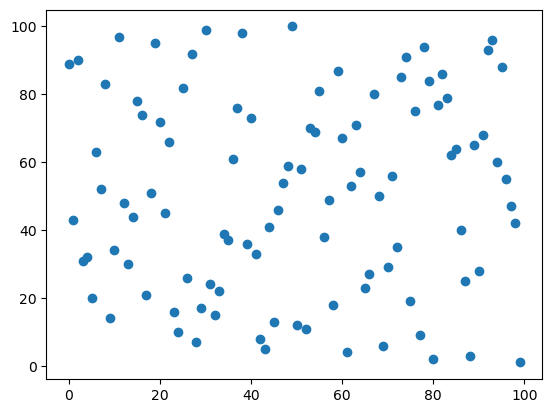

In [1]:
# (b)
import numpy as np
import numpy.random as nr
import matplotlib.pyplot as plt
from scipy.special import gamma


def LCG(x, n, a, c, m, isNormalized=False):
    '''
    x: Initial seed
    n: length of random number list
    a, c, m: LCG parameters
    '''

    if isNormalized: 
        norm = m
        X = np.zeros((n), dtype=float)
        x /= norm
    else: 
        norm = 1
        X = np.zeros((n), dtype=int)

    for i in range(n):
        x = (a*x + c)%m
        X[i] = x/norm

    return X


r = LCG(1, 100, 89, 0, 101)
plt.plot(r, 'o')
plt.show()

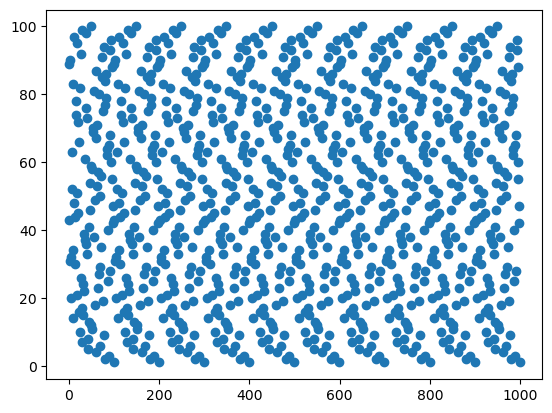

In [2]:
# (c)

r = LCG(1, 1000, 89, 0, 101)
plt.plot(r, 'o')
plt.show()

We can find some patterns of random numbers

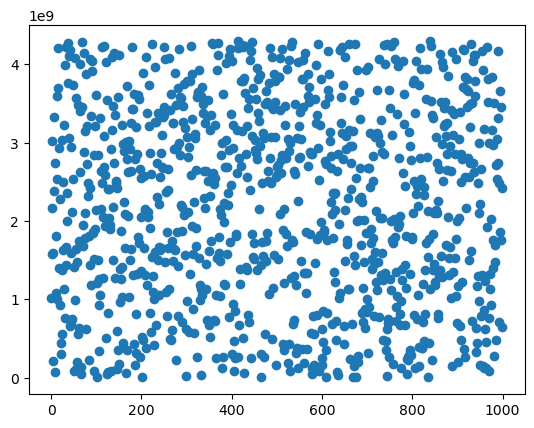

In [3]:
# (d)

r = LCG(1, 1000, 1664525, 1013904223, 4294967296)
plt.plot(r, 'o')
plt.show()

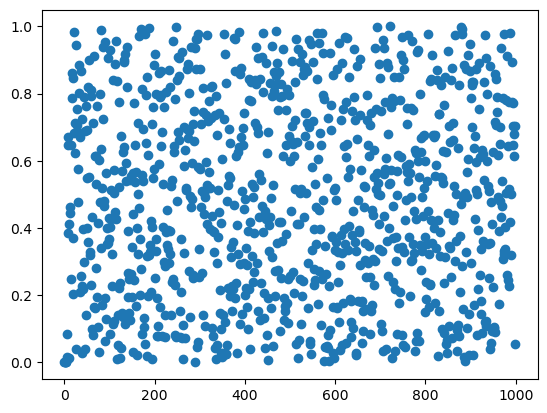

In [4]:
# (e): RANDU

r = LCG(0.5, 1000, 65539, 0, 2**31, isNormalized=True)
plt.plot(r, 'o')
plt.show()


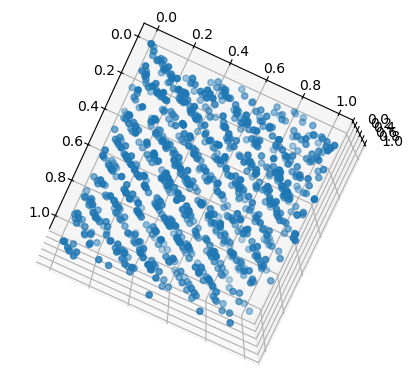

In [5]:
# (f)

n = len(r)
X = np.zeros((n-2, 3), dtype=float)

for i in range(n-2):
    X[i] = (r[i], r[i+1], r[i+2])

fig = plt.figure()
ax = plt.axes(projection="3d")
ax.scatter(X[:,0], X[:,1], X[:,2])
ax.view_init(elev=80, azim=-156, roll=179)
plt.show()


We can find that random numbers generated by RANDU is highly correlated: The random numbers are aligned in the parallel planes.

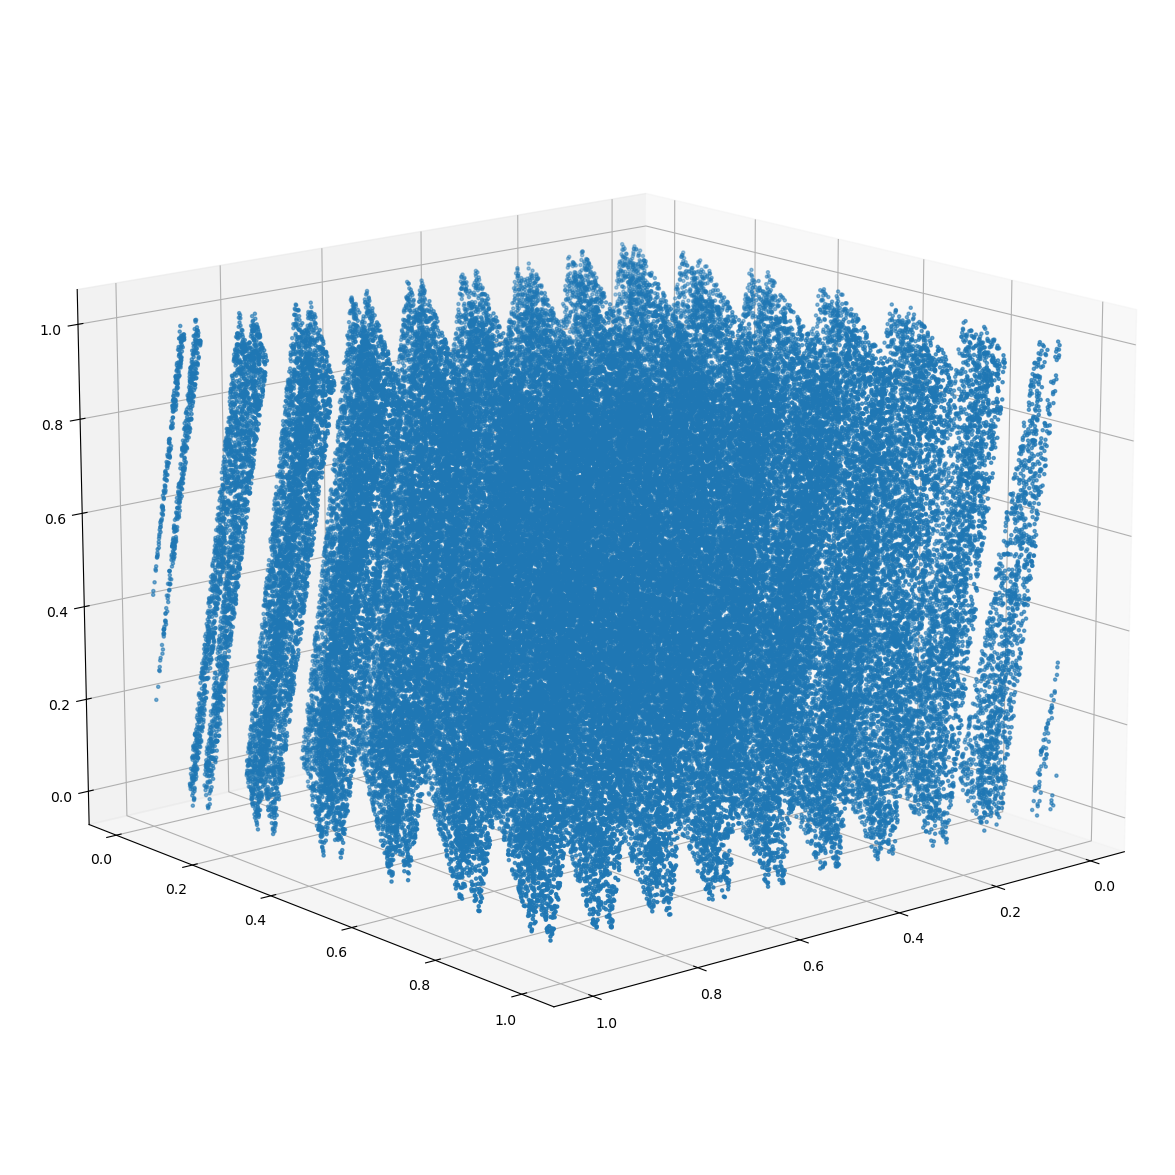

In [6]:
# (g)

r = LCG(0.5, 100000, 65539, 0, 2**31, isNormalized=True)
n = len(r)
X = np.zeros((n-2, 3), dtype=float)

for i in range(n-2):
    X[i] = (r[i], r[i+1], r[i+2])

fig = plt.figure(figsize=(15, 15))
ax = plt.axes(projection="3d")
ax.scatter(X[:,0], X[:,1], X[:,2], s=5)
ax.view_init(elev=15, azim=50, roll=0)
plt.show()

In my RANDU implementation, I observed 30 planes. However, since some planes are close together in pairs, at lower resolution they may looks like 15 planes instead of 30.

## Problem 2

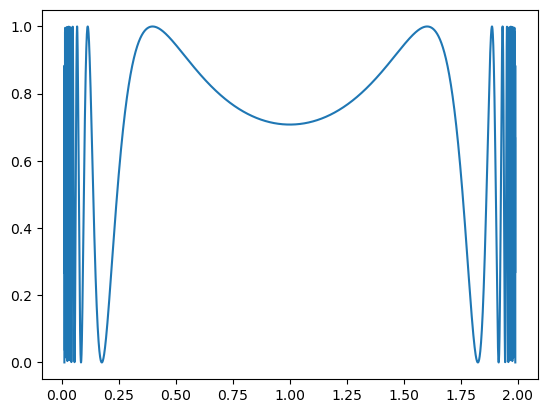

In [7]:
def f(x):
    # integrand
    # [0, 2]
    return np.sin(1/(x*(2-x)))**2


def Trapez(f, N, a, b):
    # Trapezoid method
    x = np.linspace(a, b, N + 1)
    h = (b - a)/N
    y = f(x)
    A = y[:-1] + y[1:]
    I = np.sum(A)*h*0.5

    return I


def Simpson(f, N, a, b):
    # Simpson's rule
    x = np.linspace(a, b, N + 1)
    h = (b - a)/N
    y = f(x)
    A = y[:-2:2] + y[2::2] + 4*y[1:-1:2]
    I = np.sum(A)*h/3

    return I


def Romberg(method, f, a, b):
    N = 10**4 # Number of grid points
    iterNum = 16 # Number of Romberg iteration
    values = np.zeros((iterNum), dtype=float) # Integration result
    error = np.zeros((len(values)-1), dtype=float) # Errors 

    for i in range(iterNum):
        R_now = np.zeros((i + 1), dtype=float) # array for R_{i, m}
        R_now[0] = method(f, N, a, b) # Numerical Integration

        for j in range(1, i+1):
            R_now[j] = R_now[j-1] + 1/(4**j - 1)*(R_now[j-1] - R_prev[j-1])
        
        if (i >= 1):
            error[i-1] = (R_now[-2] - R_prev[-1])/(4**i - 1)

        print(i, R_now[-1])
        values[i] = R_now[-1]
        R_prev = np.copy(R_now) # array for R_{i-1, m}
        N *= 2

    return values, error


x = np.linspace(0.01, 1.99, 5000)
y = f(x)
plt.plot(x, y)
plt.show()

0 1.4507185198838775
1 1.4498166280607234
2 1.4502950333344418
3 1.4503666245841162
4 1.4503440326927413
5 1.4504555835056288
6 1.450390644420864
7 1.4504009760830252
8 1.4504004840670615
9 1.4504004903933072
10 1.4504004903727694
11 1.4504004903727832
12 1.4504004903727852
13 1.4504004903727785
14 1.450400490372799
15 1.4504004903727856


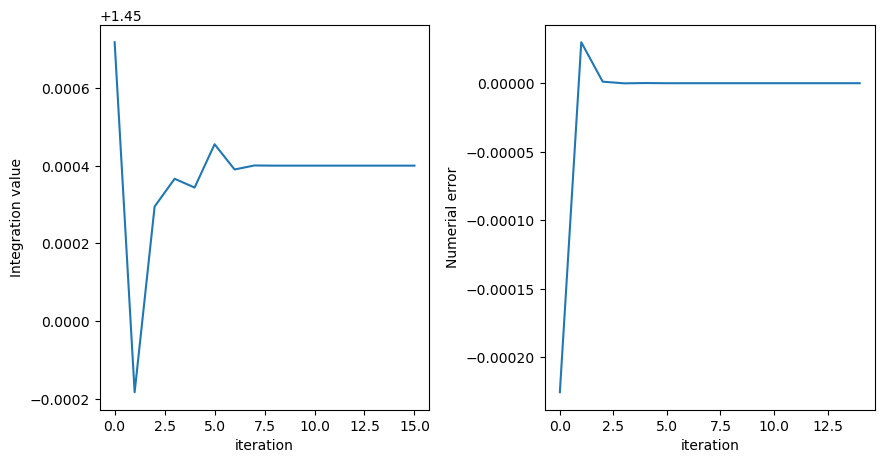

In [8]:
# (a): Trapezoid rule

I_t, error_t = Romberg(Trapez, f, 0.001, 1.999)

plt.figure(figsize=(10, 5))

plt.subplot(121)
plt.plot(I_t)
plt.xlabel('iteration')
plt.ylabel('Integration value')

plt.subplot(122)
plt.plot(error_t)
plt.xlabel('iteration')
plt.ylabel('Numerial error')

plt.subplots_adjust(wspace=0.35)

plt.show()


0 1.450561105729496
1 1.4495684688377992
2 1.4504710457072096
3 1.4503876944868201
4 1.4503364194352135
5 1.4504927745520155
6 1.4503689889772118
7 1.450404421292237
8 1.4504003200091693
9 1.4504004925026823
10 1.450400490365921
11 1.4504004903727923
12 1.4504004903727872
13 1.450400490372781
14 1.450400490372784
15 1.4504004903727756


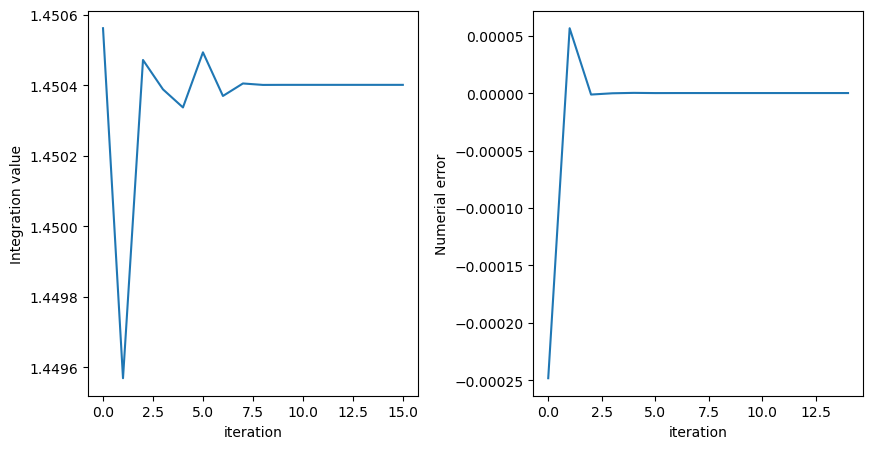

In [9]:
# (b): Simpson's rule

I_s, error_s = Romberg(Simpson, f, 0.001, 1.999)

plt.figure(figsize=(10, 5))

plt.subplot(121)
plt.plot(I_s)
plt.xlabel('iteration')
plt.ylabel('Integration value')

plt.subplot(122)
plt.plot(error_s)
plt.xlabel('iteration')
plt.ylabel('Numerial error')

plt.subplots_adjust(wspace=0.35)

plt.show()

N=10000


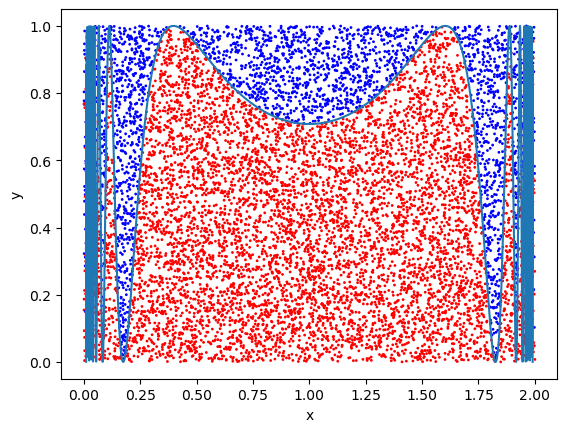

0 1.4438
1 1.4634
2 1.454
3 1.451725
4 1.4524625
5 1.450325
6 1.452121875
7 1.452209375
8 1.4504828125
9 1.451140234375
10 1.4518015625
11 1.451413671875
12 1.4515900390625
13 1.4514158203125
14 1.45130927734375
15 1.4514290954589844
N=655360000


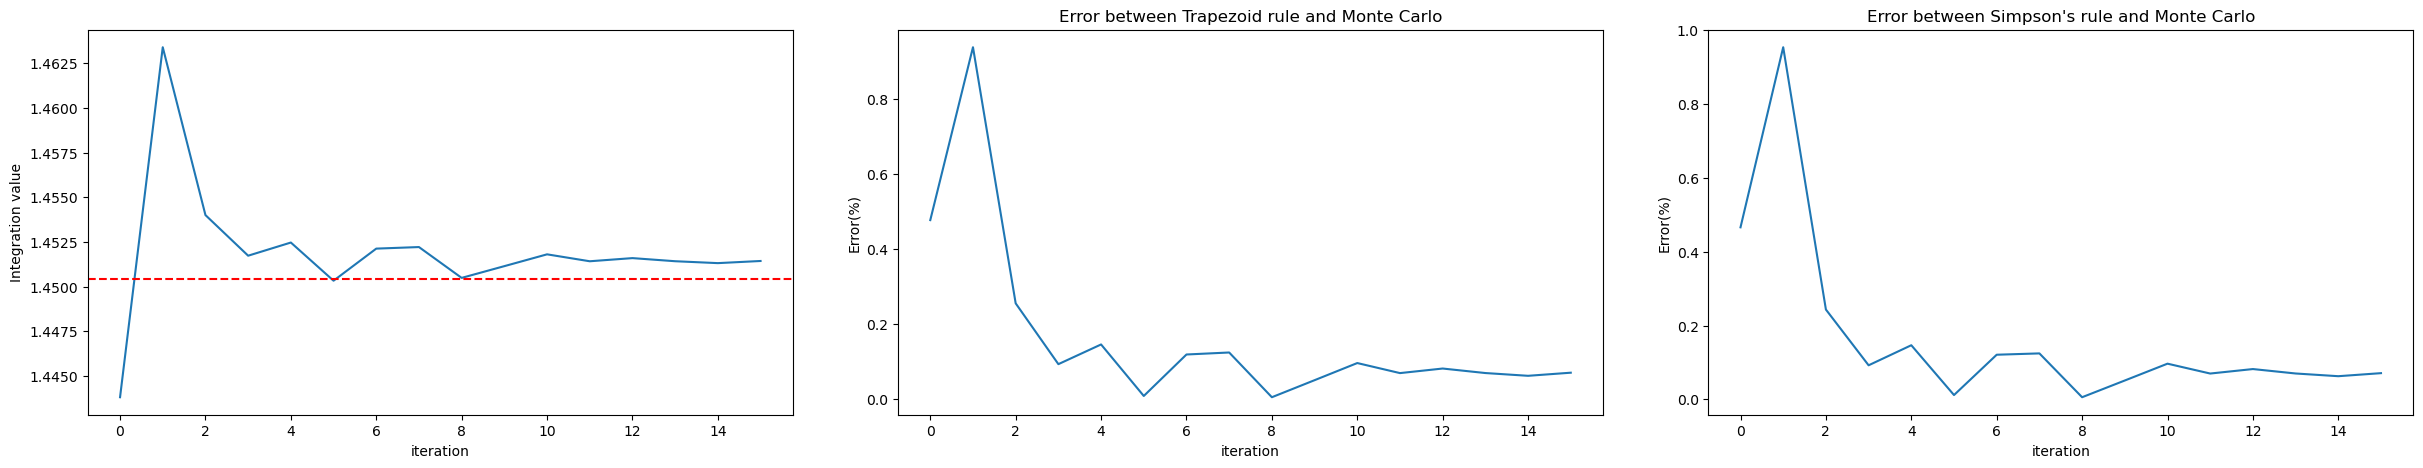

In [10]:
# (c): Monte Carlo integration

I_m = np.zeros(16, dtype='float64')
N = 10**4
print(f"N={N}")

for i in range(16):
    xr = nr.rand(N)*2 # randon numbers fo x in [0,2]
    yr = nr.rand(N) # randon numbers fo y in [0,1]
    Y = f(xr)

    k = yr < Y
    I_m[i] = 2*k.sum()/N
    
    N *= 2

    if i == 0:
        plt.plot(x, y)
        plt.scatter(xr, yr, s=1, c=k, cmap='bwr')
        plt.xlabel('x')
        plt.ylabel('y')
        plt.show()

    print(i, I_m[i])

print(f"N={N}")

error_ms = np.abs((I_s - I_m)/I_s)*100
error_mt = np.abs((I_t - I_m)/I_t)*100

plt.figure(figsize=(30, 5))

plt.subplot(131)
plt.plot(I_m)
plt.axhline(y=1.4504, color='r', linestyle='--')
plt.xlabel('iteration')
plt.ylabel('Integration value')

plt.subplot(132)
plt.plot(error_mt)
plt.xlabel('iteration')
plt.ylabel('Error(%)')
plt.title('Error between Trapezoid rule and Monte Carlo')

plt.subplot(133)
plt.plot(error_ms)
plt.xlabel('iteration')
plt.ylabel('Error(%)')
plt.title("Error between Simpson's rule and Monte Carlo")

plt.subplots_adjust(wspace=0.15)

plt.show()




The left pannel is result of Monte Carlo method and red dashed line is $I=1.4504$ which is the result of Trapezoid rule and Simpson's rule. Compare to Trapezoid rule and Simpson's rule, Monte Carlo method converges slowly.

## Problem 3

The volume of $n$-dimensional hypersphere is defined as
$
\begin{gather}
    V_n(R)=\frac{\pi^{n/2}}{\Gamma\bigg(\dfrac{n}{2}+1\bigg)}R^n~,
\end{gather}
$
with the gamma function $\Gamma(z)$. In case of unit hypersphere, $R=1$,
$
\begin{gather}
    V_n=\frac{\pi^{n/2}}{\Gamma\bigg(\dfrac{n}{2}+1\bigg)}~.
\end{gather}
$
We can obtain the value of $V_n$ via numerical approach also.

### (a)
The volume of unit hypersphere in 2-dimensional space is
$
\begin{gather}
    V_2=\frac{\pi}{\Gamma(2)}=\frac{\pi}{1!}=\pi
\end{gather}
$



In [11]:
N = 1000000
x1 = nr.rand(N)*2 - 1 # random numbers fo x1 in [-1,1]
x2 = nr.rand(N)*2 - 1 # random numbers fo x2 in [-1,1]
r = x1**2 + x2**2

k = r < 1
I = 4*k.sum()/N
print(f"Monte Carlo: {I}")
print(f"Exact value: {np.pi}")


Monte Carlo: 3.143752
Exact value: 3.141592653589793


### (b)
The volume of unit hypersphere in 3-dimensional space is
$
\begin{gather}
    V_3=\frac{\pi^{3/2}}{\Gamma(5/2)}=\frac{\pi^{3/2}}{3\pi^{1/2}/4}=\frac{4}{3}\pi~.
\end{gather}
$


In [12]:
N = 1000000
x1 = nr.rand(N)*2 - 1 # random numbers for x1 in [-1,1]
x2 = nr.rand(N)*2 - 1 # random numbers for x2 in [-1,1]
x3 = nr.rand(N)*2 - 1 # random numbers for x3 in [-1,1]
r = x1**2 + x2**2 + x3**2

k = r < 1
I = 8*k.sum()/N
print(f"Monte Carlo: {I}")
print(f"Exact value: {4*np.pi/3}")


Monte Carlo: 4.192376
Exact value: 4.1887902047863905


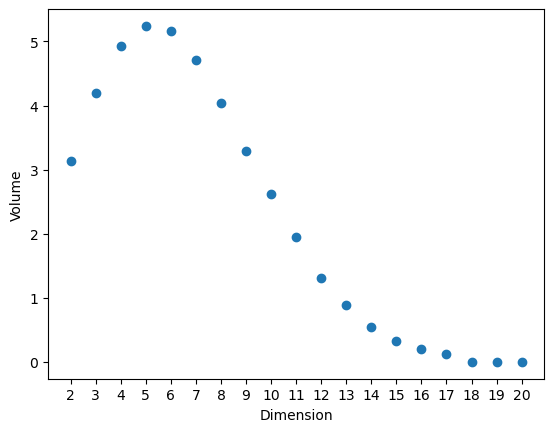

In [13]:
# (c): 2D to 20D


@np.vectorize
def Vn_MonteCarlo(n, N=1000000):
    '''
    Volume of n-dimensional unit hypersphere

    n: dimension
    N: total number of random points
    '''

    X = nr.rand(N, n)*2 - 1 # random numbers in [-1,1]
    r = np.sum(X**2, axis=1)

    k = r < 1
    I = (2**n)*k.sum()/N

    return I


nr.seed(2)
n = np.arange(2, 21)
V_numerical = Vn_MonteCarlo(n)

plt.plot(n, V_numerical, 'o')
plt.xlabel('Dimension')
plt.ylabel('Volume')
plt.xticks(n)
plt.show()

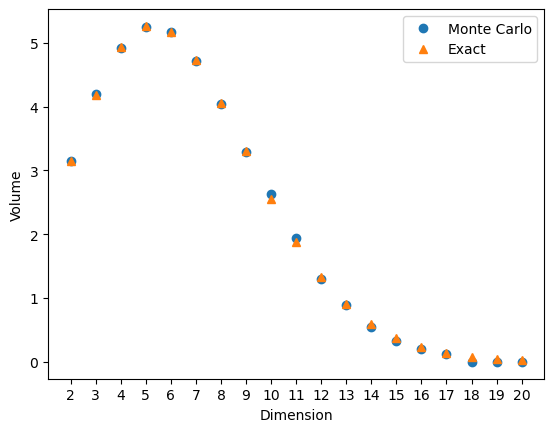

In [14]:
# (d)

def Vn_Exact(n):
    # Volume of n-dimensional unit hypersphere
    V = np.pi**(n/2)/gamma(n/2 + 1) 
    return V

V_exact = Vn_Exact(n)

plt.plot(n, V_numerical, 'o', label='Monte Carlo')
plt.plot(n, V_exact, '^', label='Exact')
plt.xlabel('Dimension')
plt.ylabel('Volume')
plt.legend()
plt.xticks(n)
plt.show()